# Logistic Regression and kNN Classification

- Group: Group 1 (Mason DeWitt, Elena Van, Prithvi Ghale)
- Dataset: Dataset 5 (Department Shift)

In [1]:
import pandas as pd
df = pd.read_csv("../datasets/synthetic_classification_group_1.csv")

## I - Define the Modeling Problem

This is a **binary classification** problem. Each record represents one synthetic student. The goal is to predict which students require academic support before they can be identified through conventional means.

## Target variable (y):
- Risk of academic decline (`Risk`)
- `Risk = 1` is the **positive class:** *the synthetic student requires support*
- `Risk = 0` is the **negative class:** *the synthetic student does not require support*

## Predictors (X):
- Hours studied per week (`Hours_Studied`)
- Percentage of class attendance (`Attendance_Pct`)
- Previous semester GPA (`Previous_GPA`)
- Number of assignments completed (`Assignments_Completed`)
- Average quiz score (`Quiz_Average`)
- Number of hours slept (`Sleep_Hours`)
- Self-reported stress level (`Stress_Level`)
- Daily commute time in minutes (`Commute_Minutes`)
- Weekly social hours (`Social_Hours`)
- Daily caffeine consumption in cups (`Caffeine_Cups`)

Each record's unique ID (`Synthetic_Record_ID`) is excluded because it is only an identifier. Additionally, each record's train/test assignment `Split` is excluded. Neither of these columns describe the synthetic student and they are excluded from all modeling.

## Dataset Variation: Test population shift

In this dataset, the testing data was taken from a *different population* than the train data. This is an extremely bad practice in **machine learning.** We expect this variation to degrade the model's performance, as separate populations can be vastly different in behavior.

Regardless of variation, we must first separate the training data from testing data before modeling.

In [2]:
numeric_features = [
    "Hours_Studied",
    "Attendance_Pct",
    "Previous_GPA",
    "Assignments_Completed",
    "Quiz_Average",
    "Sleep_Hours",
    "Stress_Level",
    "Commute_Minutes",
    "Social_Hours",
    "Caffeine_Cups"
]

# Use the provided Split column to create the fixed train/test partition
train_data = df["Split"] == "train"
test_data  = df["Split"] == "test"

X_train = df.loc[train_data, numeric_features]
X_test  = df.loc[test_data,  numeric_features]
y_train = df.loc[train_data, "Risk"]
y_test  = df.loc[test_data,  "Risk"]

## II - Inspect Data and the Fixed Split

This step checks the quality of the dataset and the fixed train/test split before building any models. We check dataset size, split sizes, missing values, duplicate identifiers, summary statistics, plausible value ranges, class proportions, variable correlations, train vs. test distributions, and unusual observations.

### Records and Fields

Each **row** of the dataset is one observation (a synthetic student) and each **column** is one variable. The `Split` column assigns each row to the training or test partition.

In [3]:
train_df = df[df["Split"] == "train"]
test_df  = df[df["Split"] == "test"]

print(f"Total records (rows):   {df.shape[0]}")
print(f"Total fields (columns): {df.shape[1]}")
print(f"\nTrain rows: {len(train_df)}  |  Test rows: {len(test_df)}")
print()
print("Column data types:")
print(df.dtypes)

Total records (rows):   1000
Total fields (columns): 13

Train rows: 750  |  Test rows: 250

Column data types:
Synthetic_Record_ID       object
Hours_Studied            float64
Attendance_Pct           float64
Previous_GPA             float64
Assignments_Completed      int64
Quiz_Average             float64
Sleep_Hours              float64
Stress_Level               int64
Commute_Minutes          float64
Social_Hours             float64
Caffeine_Cups              int64
Split                     object
Risk                       int64
dtype: object


### Missing Values

A missing value is a blank cell. We must verify that there are none in the dataset before modeling.

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing.to_string())
print(f"\nTotal missing cells: {missing.sum()}\n")

if missing.sum() > 0: print("Missing values detected, data must be manually reviewed")
else: print("No missing values detected, safe to proceed")

Missing values per column:
Synthetic_Record_ID      0
Hours_Studied            0
Attendance_Pct           0
Previous_GPA             0
Assignments_Completed    0
Quiz_Average             0
Sleep_Hours              0
Stress_Level             0
Commute_Minutes          0
Social_Hours             0
Caffeine_Cups            0
Split                    0
Risk                     0

Total missing cells: 0

No missing values detected, safe to proceed


### Duplicate Identifiers

If the same student appears twice under the same `Synthetic_Record_ID`, the model counts their data twice. We must remove any duplicates before modeling.

In [5]:
num_dupes = df['Synthetic_Record_ID'].duplicated().sum()
print(f"Duplicate Synthetic_Record_IDs: {num_dupes}\n")

if num_dupes: print("Duplicate identifiers detected, manual review required")
else: print("No duplicated identifiers detected, safe to proceed")

Duplicate Synthetic_Record_IDs: 0

No duplicated identifiers detected, safe to proceed


### Summary Statistics

Summary statistics compress each column into descriptive values that describe their shape. Because the train and test rows may come from different synthetic populations, summary statistics are generated separately.

In [6]:
pd.set_option('display.precision', 2)
print("Train summary statistics:")
display(train_df[numeric_features].describe())
print("\nTest summary statistics:")
display(test_df[numeric_features].describe())

Train summary statistics:


,Hours_Studied,Attendance_Pct,Previous_GPA,Assignments_Completed,Quiz_Average,Sleep_Hours,Stress_Level,Commute_Minutes,Social_Hours,Caffeine_Cups
count,750.00,750.00,750.00,750.00,750.00,750.00,750.00,750.00,750.00,750.00
mean,8.86,81.44,2.78,6.89,73.83,6.97,5.09,25.93,7.00,2.22
std,3.25,9.19,0.43,1.60,9.72,0.76,1.77,16.96,2.25,1.50
min,1.00,53.07,1.40,2.00,44.48,4.27,1.00,2.00,0.00,0.00
25%,6.61,75.31,2.48,6.00,67.73,6.45,4.00,13.51,5.34,1.00
50%,8.77,81.56,2.78,7.00,74.01,6.95,5.00,22.42,6.97,2.00
75%,11.20,87.67,3.08,8.00,80.57,7.50,6.00,33.90,8.50,3.00
max,18.39,100.00,4.00,10.00,100.00,9.17,10.00,90.00,13.54,8.00



Test summary statistics:


,Hours_Studied,Attendance_Pct,Previous_GPA,Assignments_Completed,Quiz_Average,Sleep_Hours,Stress_Level,Commute_Minutes,Social_Hours,Caffeine_Cups
count,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00,250.00
mean,9.63,83.03,2.76,6.84,73.85,8.25,4.54,61.11,12.38,6.03
std,3.59,9.31,0.42,1.55,10.50,0.73,1.81,14.14,2.23,1.28
min,1.00,56.23,1.44,3.00,48.51,6.13,1.00,38.08,5.57,4.00
25%,7.06,76.03,2.46,6.00,66.27,7.75,3.00,49.49,11.03,5.00
50%,9.48,83.08,2.76,7.00,74.00,8.20,5.00,59.12,12.36,6.00
75%,11.98,89.12,3.03,8.00,80.91,8.76,6.00,70.90,14.09,7.00
max,18.84,100.00,3.81,10.00,100.00,9.70,9.00,90.00,16.00,8.00


### Plausible Value Ranges

Even with no missing values, a column can contain impossible values. For example, `Attendance_Pct` must be between `0` and `100`, `Previous_GPA` must fall between `0.0` and `4.0`, and `Stress_Level` is recorded on a `1–10` scale.

In [7]:
bounds = {
    'Hours_Studied':         (0, None),   # 0 or more hours studied
    'Attendance_Pct':        (0, 100),    # 0–100 percent attendance
    'Previous_GPA':          (0.0, 4.0), # 0.0–4.0 GPA scale
    'Assignments_Completed': (0, None),   # 0 or more assignments
    'Quiz_Average':          (0, 100),    # 0–100 quiz score
    'Sleep_Hours':           (0, 24),     # 0–24 hours of sleep
    'Stress_Level':          (1, 10),     # 1–10 self-reported scale
    'Commute_Minutes':       (0, None),   # 0 or more minutes
    'Social_Hours':          (0, None),   # 0 or more hours
    'Caffeine_Cups':         (0, None),   # 0 or more cups
    'Risk':                  (0, 1),      # binary value
}

print("Plausible range check:")
all_clean = True
for col, (lo, hi) in bounds.items():
    mask = pd.Series(False, index=df.index)
    if lo is not None:
        mask |= (df[col] < lo)
    if hi is not None:
        mask |= (df[col] > hi)
    flagged = df.loc[mask, ['Synthetic_Record_ID', col]]
    if flagged.empty:
        print(f"  {col}: OK")
    else:
        print(f"  {col}: {len(flagged)} out-of-range value(s)")
        print(flagged.to_string(index=False))
        all_clean = False

if all_clean: print("\nAll values within plausible bounds, safe to proceed")
else: print("\nValues detected outside of their plausible bounds, manual review required")

Plausible range check:
  Hours_Studied: OK
  Attendance_Pct: OK
  Previous_GPA: OK
  Assignments_Completed: OK
  Quiz_Average: OK
  Sleep_Hours: OK
  Stress_Level: OK
  Commute_Minutes: OK
  Social_Hours: OK
  Caffeine_Cups: OK
  Risk: OK

All values within plausible bounds, safe to proceed


### Class Proportions

In classification, the proportion of each class matters. An imbalanced dataset where one class dominates can cause the model to almost always choose the majority class. We check class balance for the entire dataset as well as the training and testing data separately.

In [8]:
print("Overall class proportions (full dataset):\n")
counts_all = df["Risk"].value_counts().sort_index()
props_all  = df["Risk"].value_counts(normalize=True).sort_index()
for label in [0, 1]:
    label_str = "No risk (0)" if label == 0 else "At risk  (1)"
    print(f"  Risk={label}  {label_str}:  {counts_all[label]:4d}  ({props_all[label]:.1%})")

print("\nClass proportions by split:\n")
for split_name, subset in [("Train", train_df), ("Test", test_df)]:
    counts = subset["Risk"].value_counts().sort_index()
    props  = subset["Risk"].value_counts(normalize=True).sort_index()
    print(f"  {split_name}  (n={len(subset)})")
    for label in [0, 1]:
        label_str = "No risk (0)" if label == 0 else "At risk  (1)"
        print(f"    Risk={label}  {label_str}:  {counts[label]:4d}  ({props[label]:.1%})")
    print()

Overall class proportions (full dataset):

  Risk=0  No risk (0):   631  (63.1%)
  Risk=1  At risk  (1):   369  (36.9%)

Class proportions by split:

  Train  (n=750)
    Risk=0  No risk (0):   472  (62.9%)
    Risk=1  At risk  (1):   278  (37.1%)

  Test  (n=250)
    Risk=0  No risk (0):   159  (63.6%)
    Risk=1  At risk  (1):    91  (36.4%)



A class proportion of roughly 50/50 makes model training straightforward. A meaningful imbalance means the majority-class baseline — a model that always predicts the larger class — can achieve high accuracy without learning anything. If the proportion shifts between train and test, threshold-based metrics like accuracy may not reflect true generalization.

### Variable Correlation

Correlation shows the strength and direction of the linear relationship between two numerical variables.

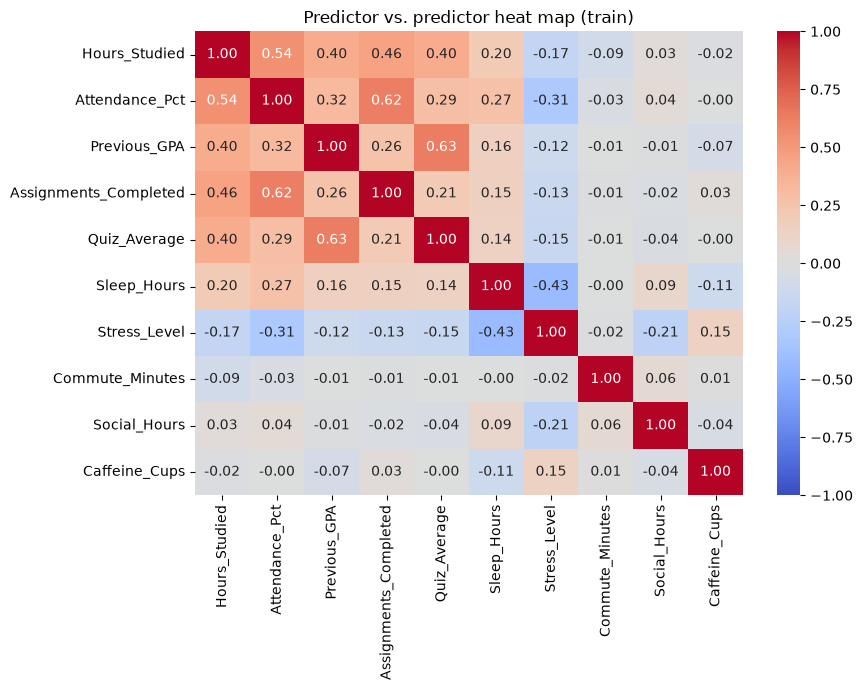

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predictor vs. predictor correlation heatmap (train only)
corr = train_df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Predictor vs. predictor heat map (train)')
plt.tight_layout()
plt.show()

In the above heatmap, correlation is represented by a value ranging from `-1` to `1`

- **Closer to `+1`:** *Strong positive relationship* — as one variable increases, the other increases
- **Closer to `-1`:** *Strong negative relationship* — as one variable increases, the other decreases
- **Closer to `0`:** *Weak linear relationship* — little to no linear association between the two variables

Highly correlated predictors are a concern in both models. In logistic regression, they share overlapping information and can make coefficient estimates unstable — the model has difficulty deciding how much credit to give each one. In kNN, they cause *"double weighting,"* where the distance calculation is pulled in the same direction twice as much as it should be.

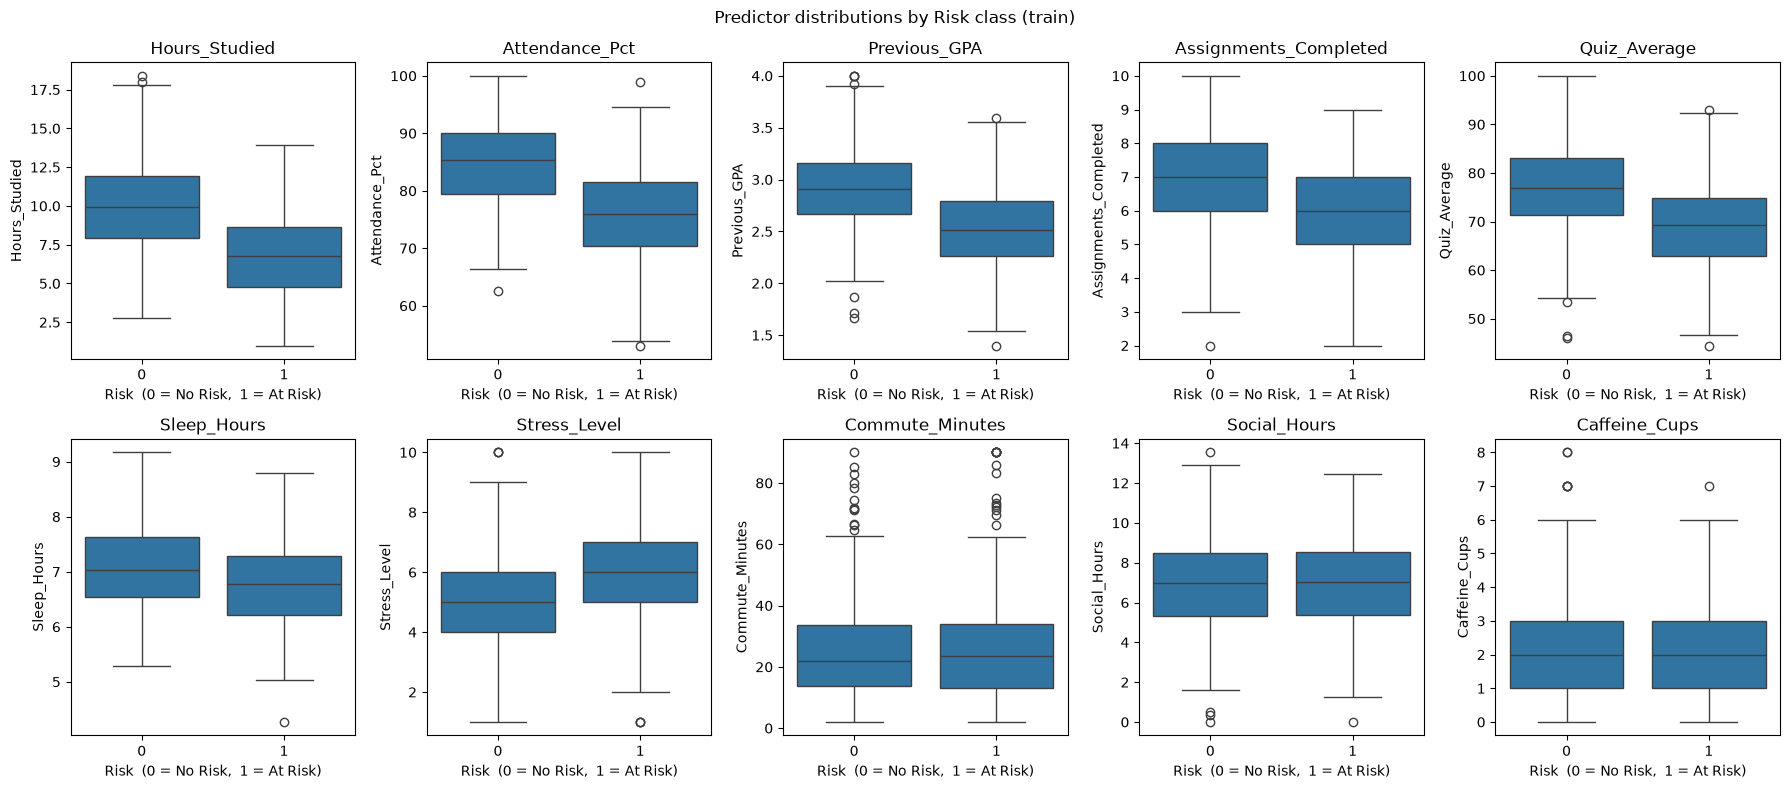

In [10]:
# Predictor distributions by Risk class (train only)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x='Risk', y=col, data=train_df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Risk  (0 = No Risk,  1 = At Risk)')

plt.suptitle('Predictor distributions by Risk class (train)')
plt.tight_layout()
plt.show()

### Train vs Test Distribution

Because Group 1 uses a **test population shift**, the test rows may have been drawn from a different synthetic population than the training rows. Comparing predictor means and standard deviations across the two splits reveals which predictors shifted the most.

A large mean shift in a predictor means the model will encounter values during testing that look different from what it was trained on. This matters differently for the two models:

- **Logistic regression** fits a fixed linear decision boundary during training. If a predictor's distribution shifts at test time, the boundary may no longer sit in the right place relative to the new data.
- **kNN** predicts by finding the nearest training-set neighbors. If the test records cluster in a part of the predictor space that the training set barely covered, the nearest neighbors may be far away and the prediction less reliable.

Model choices are made using training rows only. The test outcomes (`y_test`) are kept untouched until final evaluation.

In [11]:
dist_comparison = pd.DataFrame({
    "Train Mean": train_df[numeric_features].mean(),
    "Test Mean":  test_df[numeric_features].mean(),
    "Train Std":  train_df[numeric_features].std(),
    "Test Std":   test_df[numeric_features].std(),
})
dist_comparison["Mean Shift"] = (dist_comparison["Test Mean"] - dist_comparison["Train Mean"]).abs()
dist_comparison.round(2).sort_values("Mean Shift", ascending=False)

,Train Mean,Test Mean,Train Std,Test Std,Mean Shift
Commute_Minutes,25.93,61.11,16.96,14.14,35.17
Social_Hours,7.00,12.38,2.25,2.23,5.39
Caffeine_Cups,2.22,6.03,1.50,1.28,3.81
Attendance_Pct,81.44,83.03,9.19,9.31,1.58
Sleep_Hours,6.97,8.25,0.76,0.73,1.28
Hours_Studied,8.86,9.63,3.25,3.59,0.78
Stress_Level,5.09,4.54,1.77,1.81,0.55
Assignments_Completed,6.89,6.84,1.60,1.55,0.04
Quiz_Average,73.83,73.85,9.72,10.50,0.02
Previous_GPA,2.78,2.76,0.43,0.42,0.02


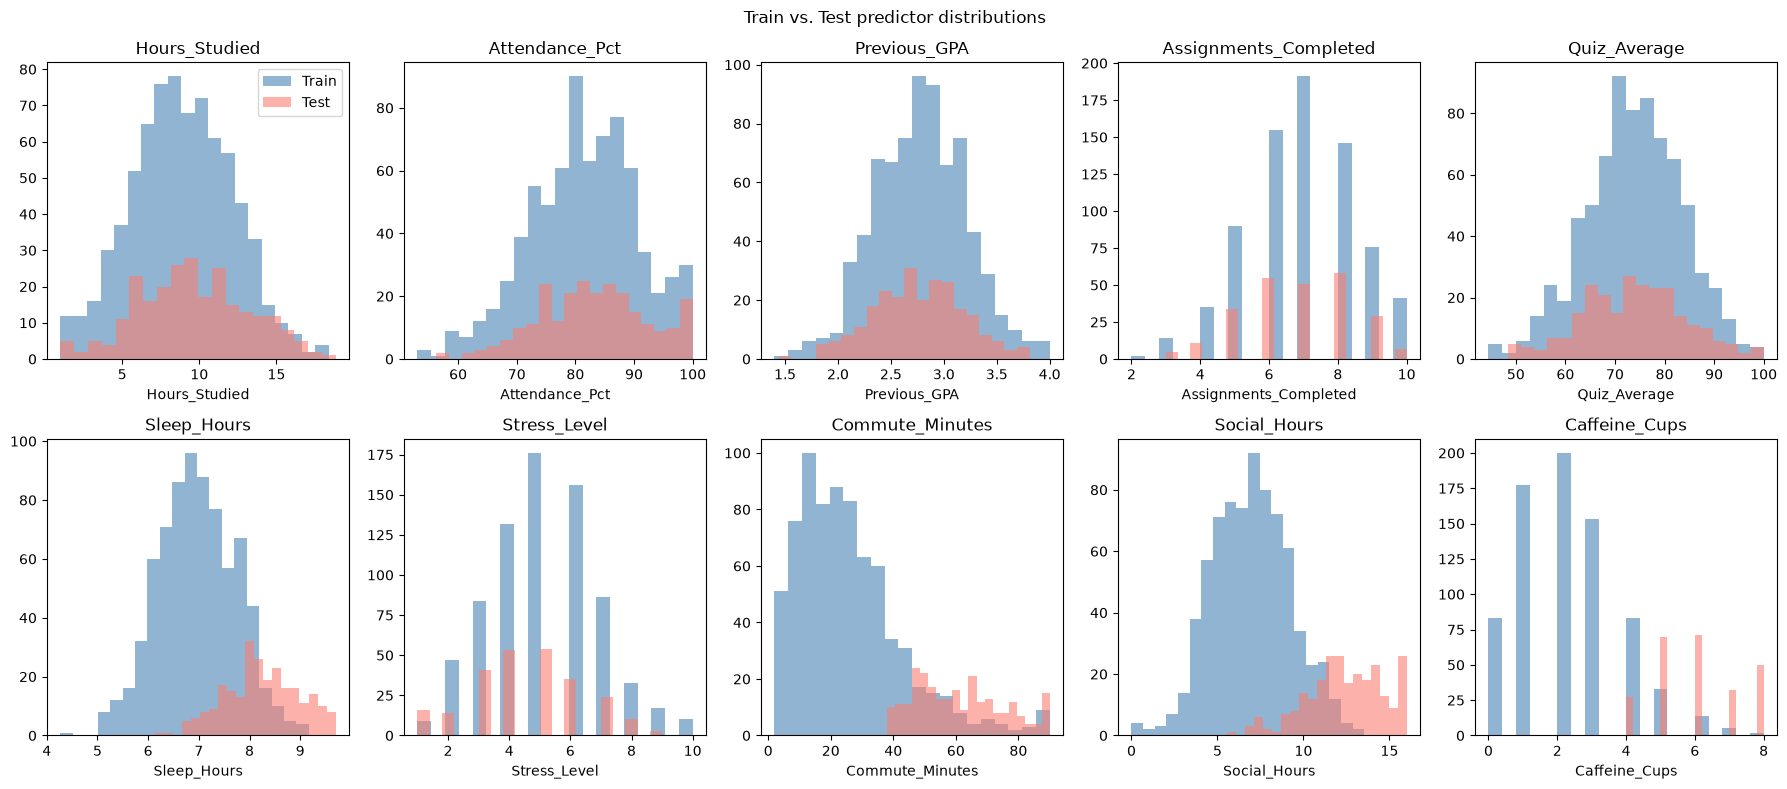

In [12]:
# Overlaid histograms — train vs test for each predictor
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(train_df[col], bins=20, alpha=0.6, label="Train", color="steelblue")
    axes[i].hist(test_df[col],  bins=20, alpha=0.6, label="Test",  color="salmon")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    if i == 0:
        axes[i].legend()

plt.suptitle('Train vs. Test predictor distributions')
plt.tight_layout()
plt.show()

### Outlier Detection

An outlier is a value that sits far from the rest of the data. Outlier detection is performed on the training set only to avoid any influence from test-set values before model choices are finalized.

In [13]:
outlier_rows = []

for col in numeric_features:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    outlier_rows.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': round(IQR, 3),
        'Lower fence': round(lower, 3),
        'Upper fence': round(upper, 3),
        'Outliers flagged': n_out
    })

outlier_df = pd.DataFrame(outlier_rows).set_index('Column')
outlier_df

,Q1,Q3,IQR,Lower fence,Upper fence,Outliers flagged
Column,,,,,,
Hours_Studied,6.61,11.20,4.59,-0.27,18.09,1
Attendance_Pct,75.31,87.67,12.35,56.78,106.19,3
Previous_GPA,2.48,3.08,0.60,1.58,3.97,6
Assignments_Completed,6.00,8.00,2.00,3.00,11.00,2
Quiz_Average,67.73,80.57,12.84,48.46,99.83,8
Sleep_Hours,6.45,7.50,1.05,4.88,9.07,2
Stress_Level,4.00,6.00,2.00,1.00,9.00,10
Commute_Minutes,13.51,33.90,20.39,-17.08,64.49,28
Social_Hours,5.34,8.50,3.15,0.61,13.23,5


The IQR method defines the fences as:

- **Lower fence:** Q1 − 1.5 × IQR
- **Upper fence:** Q3 + 1.5 × IQR

Any value outside these bounds is a potential outlier.

In logistic regression, an extreme training-set value can shift a fitted coefficient for that predictor, particularly after standardization compresses the overall scale. In kNN, a training-set outlier can become the nearest neighbor of a test point and pull the predicted probability toward the wrong class.

### Data Quality Analysis

- The dataset contains **1,000** records and **13** fields with a fixed **750-row train / 250-row test** split
    - **10** numeric predictors, **1** binary target (`Risk`), **1** identifier, **1** split column
- No missing values or duplicate identifiers were found
- All numerical variables fall within plausible bounds with no obvious abnormalities
- Class proportions are nearly identical across splits (**37.1%** at risk in train, **36.4%** in test), so the shift is in the predictors rather than the target
- Several predictors are moderately correlated in the training rows, but none strongly enough to be a serious concern:
    - `Previous_GPA` and `Quiz_Average` (**0.63**)
    - `Attendance_Pct` and `Assignments_Completed` (**0.62**)
    - `Hours_Studied` and `Attendance_Pct` (**0.54**)
    - `Sleep_Hours` and `Stress_Level` (**-0.43**)
- `Attendance_Pct`, `Hours_Studied`, `Previous_GPA`, `Assignments_Completed`, and `Quiz_Average` show the clearest separation by `Risk` class, with at-risk students scoring lower on all five. `Stress_Level` is higher for at-risk students and `Sleep_Hours` is somewhat lower. `Commute_Minutes`, `Social_Hours`, and `Caffeine_Cups` show little to no separation
- `Commute_Minutes`, `Social_Hours`, and `Caffeine_Cups` shifted the most between train and test (means up by about **35 minutes**, **5.4 hours**, and **3.8 cups**, roughly 2 to 2.5 training standard deviations each). `Sleep_Hours` also shifted by about **1.3 hours** (about 1.7 training standard deviations). The remaining predictors shifted by less than a third of a training standard deviation
    - This is large enough to be a concern: many test values sit outside the range seen in training, such as every test `Caffeine_Cups` value being 4 or higher against a training mean of 2.2
    - The three most shifted predictors are also among those with the weakest link to `Risk`, which may limit the damage to logistic regression but could still distort kNN distances
- Outliers were flagged in the training set for every predictor. The most were in `Commute_Minutes` (**28**), `Stress_Level` (**10**), and `Quiz_Average` (**8**), and the rest had between 1 and 7. All values are still within plausible bounds, so no rows were removed

## III - Prepare the Predictors

All ten predictors in Dataset 5 are numeric, so no categorical encoding is needed. `Synthetic_Record_ID` and `Split` are excluded from every model.

Preprocessing is placed **inside each pipeline** rather than applied to the data up front:

- **Standardization:** `StandardScaler` rescales each predictor to a mean of `0` and standard deviation of `1`. This matters for both models. kNN measures distance across all predictors, so a predictor with a large range (like `Commute_Minutes` or `Quiz_Average`) would otherwise dominate one with a small range (like `Previous_GPA`). Logistic regression also benefits, since standardized coefficients can be compared directly.
- **No leakage:** Inside a pipeline, the scaler learns its mean and standard deviation from the training rows only, and those same values are then applied to the test rows. Fitting the scaler on the test rows would leak test information into the model.
- **Cross-validation:** When kNN is tuned with cross-validation, the pipeline refits the scaler on each fold's training portion, so the validation fold stays unseen.

The predictors stay in their original form here. Scaling happens when each pipeline is fit.

In [14]:
# Confirm the modeled predictors are all numeric and exclude the identifier and split columns
excluded = ["Synthetic_Record_ID", "Split"]

print("Predictor data types:")
print(X_train.dtypes.to_string())
print()

non_numeric = X_train.select_dtypes(exclude="number").columns.tolist()
leaked = [col for col in excluded if col in X_train.columns or col in X_test.columns]

if non_numeric: print(f"Non-numeric predictors detected, encoding required: {non_numeric}")
else: print("All predictors are numeric, no categorical encoding needed")

if leaked: print(f"Excluded columns found in the predictors: {leaked}")
else: print("Identifier and split columns are excluded from the predictors")

Predictor data types:
Hours_Studied            float64
Attendance_Pct           float64
Previous_GPA             float64
Assignments_Completed      int64
Quiz_Average             float64
Sleep_Hours              float64
Stress_Level               int64
Commute_Minutes          float64
Social_Hours             float64
Caffeine_Cups              int64

All predictors are numeric, no categorical encoding needed
Identifier and split columns are excluded from the predictors


## IV - Fit Scaled Logistic Regression

Logistic regression models the **log-odds** of the positive class as a linear combination of the predictors:

`log(p / (1 - p)) = b0 + b1·x1 + b2·x2 + ...`

The linear score can be any number, so the **sigmoid function** converts it into a probability between `0` and `1`. A probability of `0.50` or above is predicted as `Risk = 1` at the default threshold.

The model is a pipeline of `StandardScaler` followed by `LogisticRegression(max_iter=2000)`. The scaler is fit on the training rows only, so no test information leaks into the model. Standardizing also puts every predictor on the same scale, making the coefficients directly comparable.

In [15]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Scaling is inside the pipeline so it is fit on training rows only
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])
logistic_model.fit(X_train, y_train)

logreg = logistic_model.named_steps["logreg"]

coef_table = pd.DataFrame({
    "Std Coefficient": logreg.coef_[0],
    "Odds Ratio": np.exp(logreg.coef_[0])
}, index=numeric_features)

# Order by strength of association (absolute coefficient)
coef_table = coef_table.reindex(coef_table["Std Coefficient"].abs().sort_values(ascending=False).index)

print(f"Intercept (log-odds of Risk=1 at the average student): {logreg.intercept_[0]:.3f}\n")
coef_table.round(3)

Intercept (log-odds of Risk=1 at the average student): -0.916



,Std Coefficient,Odds Ratio
Previous_GPA,-0.71,0.49
Hours_Studied,-0.69,0.50
Attendance_Pct,-0.66,0.52
Stress_Level,0.53,1.70
Quiz_Average,-0.37,0.69
Assignments_Completed,-0.37,0.69
Commute_Minutes,0.16,1.18
Social_Hours,0.10,1.11
Caffeine_Cups,-0.07,0.94
Sleep_Hours,-0.06,0.94


### Reading the Coefficients

- **Standardized coefficient:** the change in the *log-odds* of `Risk = 1` for a **1 standard deviation increase** in that predictor, holding every other modeled predictor constant. Because every predictor was standardized, coefficients are on the same scale, so larger absolute values mean a stronger association with the model's predictions.
- **Odds ratio (`exp(coefficient)`):** the *multiplicative* change in the odds of `Risk = 1` for a 1 SD increase, holding the others constant.
    - **Above `1`:** the odds of needing support go up (positive coefficient)
    - **Below `1`:** the odds of needing support go down (negative coefficient)
    - **Exactly `1`:** no change in odds (coefficient of `0`)

The coefficients describe the model fit on the **training rows only.** Predictors with large train-to-test shifts (`Commute_Minutes`, `Social_Hours`, `Caffeine_Cups`) will push the test-time linear score into a region the coefficients were never fit on, so their coefficients should be treated with extra caution when the model is evaluated on the test rows.

In [16]:
scaler = logistic_model.named_steps["scaler"]

print("Coefficient interpretations (each holding the other modeled predictors constant):\n")
for feature, sd in zip(numeric_features, scaler.scale_):
    coef = coef_table.loc[feature, "Std Coefficient"]
    odds_ratio = coef_table.loc[feature, "Odds Ratio"]
    direction = "increases" if coef > 0 else "decreases"
    pct = abs(odds_ratio - 1) * 100
    print(f"- {feature}: a 1 SD increase (about {sd:.2f} original units) multiplies the odds of "
          f"Risk=1 by {odds_ratio:.2f}, which {direction} the odds by about {pct:.0f}%.")

Coefficient interpretations (each holding the other modeled predictors constant):

- Hours_Studied: a 1 SD increase (about 3.25 original units) multiplies the odds of Risk=1 by 0.50, which decreases the odds by about 50%.
- Attendance_Pct: a 1 SD increase (about 9.18 original units) multiplies the odds of Risk=1 by 0.51, which decreases the odds by about 49%.
- Previous_GPA: a 1 SD increase (about 0.43 original units) multiplies the odds of Risk=1 by 0.49, which decreases the odds by about 51%.
- Assignments_Completed: a 1 SD increase (about 1.60 original units) multiplies the odds of Risk=1 by 0.69, which decreases the odds by about 31%.
- Quiz_Average: a 1 SD increase (about 9.72 original units) multiplies the odds of Risk=1 by 0.69, which decreases the odds by about 31%.
- Sleep_Hours: a 1 SD increase (about 0.76 original units) multiplies the odds of Risk=1 by 0.94, which decreases the odds by about 6%.
- Stress_Level: a 1 SD increase (about 1.77 original units) multiplies the odds